# Análisis de Marketing Digital y Optimización de ROI
## Evaluación de fuentes de adquisición y estrategias de conversión

Problema de negocio:** ROMI general negativo de -23.42%

**Objetivo:** Optimizar la asignación presupuestal de marketing

**Resultado clave:** Propuesta de redistribución que proyecta ROMI de +35-40%

In [1]:
#PASO 1
#ACCESO A LOS DATOS

import pandas as pd

visits = pd.read_csv("/datasets/visits_log_us.csv")
orders = pd.read_csv("/datasets/orders_log_us.csv")
costs = pd.read_csv("/datasets/costs_us.csv")

print(visits.head())
print(" ")
visits.info()
print(" ")
print(orders.head())
print(" ")
orders.info()
print(" ")
print(costs.head())
print(" ")
costs.info()

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usa

Al revisar cada DataFrame encontramos los siguiente:

Visits
Las columnas End TS y Start Ts se encuentran en formato objetc y debemos cambiarla a formato de fecha y hora. 
Las demas columnas se encuentran en un formato adecuado para trabajar. 

Orders
La columna Buy Ts se encuentra en formato object y debemos cambiarla a formato de fecha y hora. El resto de columnas son del tipo adecuado para trabajar. 

Costs
La columna dt se encuentra en formato object y debemos cambiarla a formato de fecha y hora. El resto de columnas son del tipo adecuado para trabajar. 

In [2]:
# PREPARACION DE DATOS
#Cambio de datos tipo object a tipo datetime

visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])

orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])

costs['dt'] = pd.to_datetime(costs['dt'])

visits.info()
orders.info()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2

In [3]:
#PASO 2
#Informe de visitas

visits["start date"] = visits["Start Ts"].dt.date
visits["start week"] = pd.to_datetime(visits["Start Ts"]).dt.week
visits["start month"] = pd.to_datetime(visits["Start Ts"]).dt.month

visit_stats = visits.groupby("start date").agg({'Uid': 'nunique'})
visit_stats_per_week = visits.groupby("start week").agg({'Uid': 'nunique'})
visit_stats_per_month = visits.groupby("start month").agg({'Uid': 'nunique'})

print(visit_stats.head())
print(visit_stats_per_week.head())
print(visit_stats_per_month.head())

            Uid
start date     
2017-06-01  605
2017-06-02  608
2017-06-03  445
2017-06-04  476
2017-06-05  820
             Uid
start week      
1           6918
2           6703
3           6972
4           7060
5           8111
               Uid
start month       
1            28716
2            28749
3            27473
4            21008
5            20701


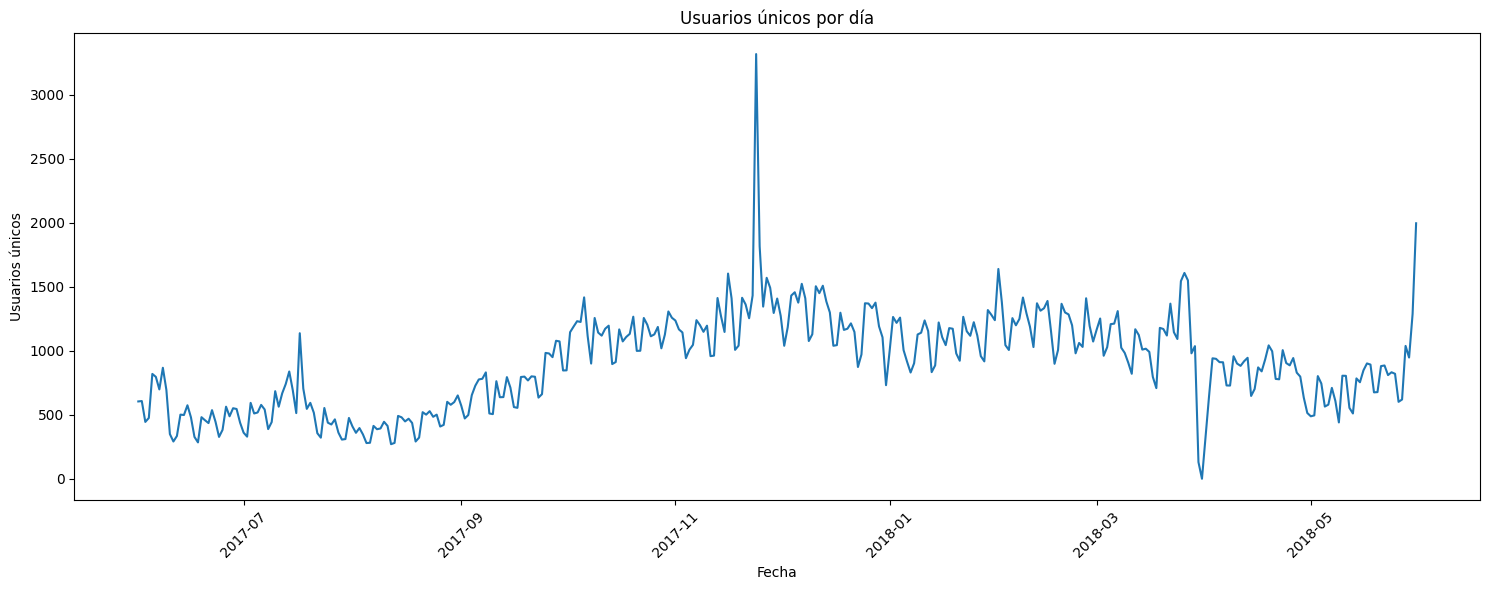

In [4]:
#Visualizacion de datos por dia

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
plt.plot(visit_stats.index, visit_stats['Uid'])
plt.title('Usuarios únicos por día')
plt.xlabel('Fecha')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

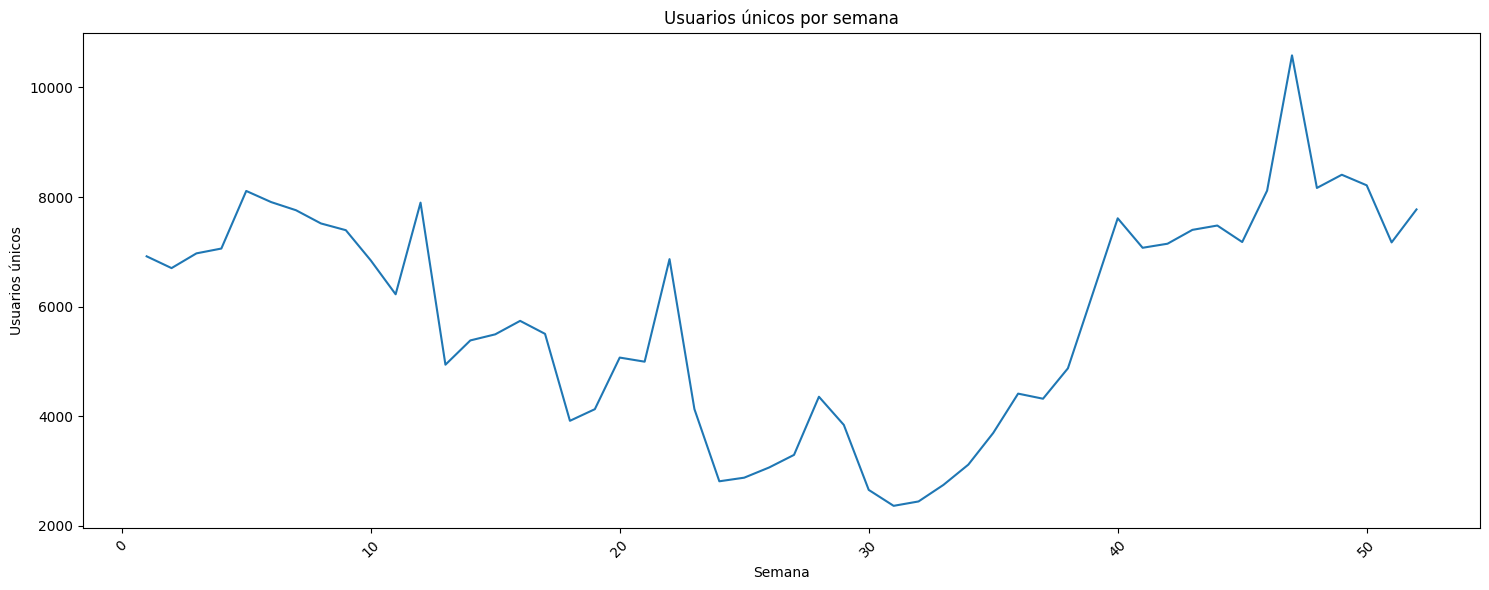

In [5]:
#Visualizacion de datos por semana

plt.figure(figsize=(15, 6))
plt.plot(visit_stats_per_week.index, visit_stats_per_week['Uid'])
plt.title('Usuarios únicos por semana')
plt.xlabel('Semana')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

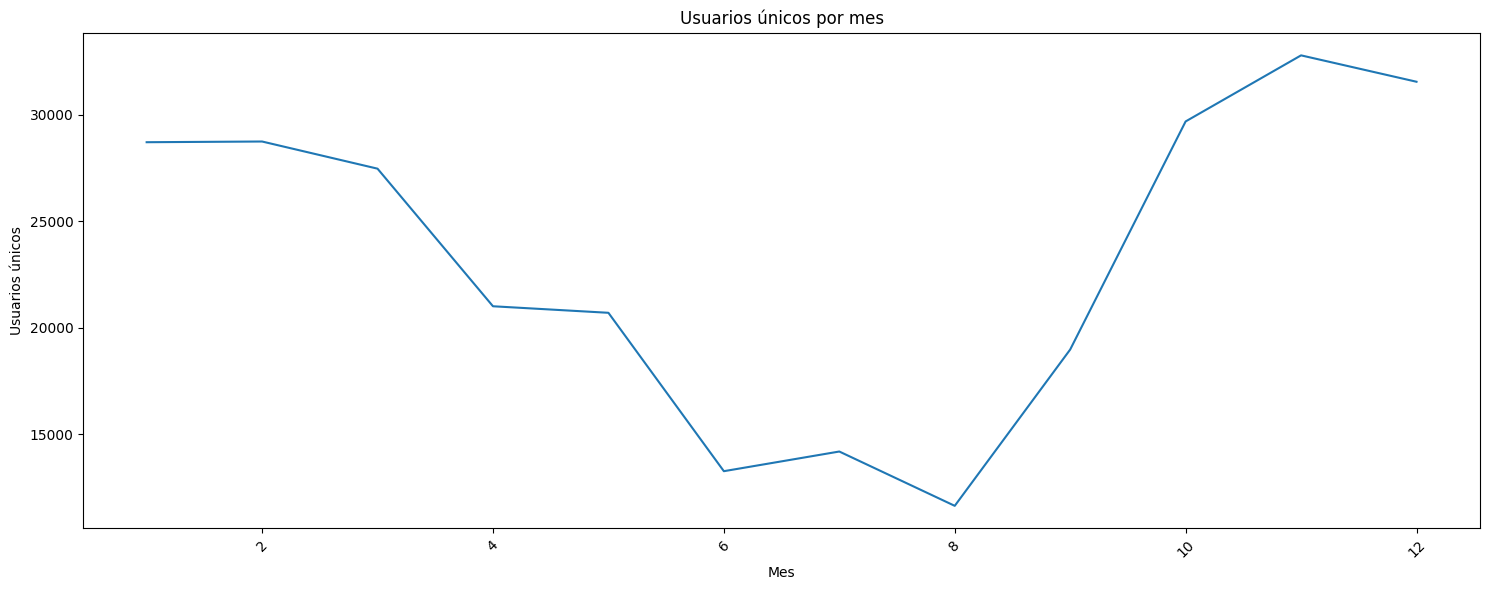

In [6]:
#Visualizacion de datos por mes

plt.figure(figsize=(15, 6))
plt.plot(visit_stats_per_month.index, visit_stats_per_month['Uid'])
plt.title('Usuarios únicos por mes')
plt.xlabel('Mes')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Luego de analizar las graficas realizadas para la visualizacion de los datos, podemos evidenciar que el comportamiento es bastante fluctuante, sin embargo si revisamos la grafica de usuarios por dia, podemos ver un pico para el mes de diciembre 2017 (aproximadamente) esto podria deverse a temas estacionales (fiestas de fin de año). Asi mismo observando las graficas de usuarios por semana y por mes podemos ver un descenso significativo en los usuarios hacia la semana 30 o entre los meses de junio, julio y agosto, para luego subir nuevamente para los ultimos meses del año. Reforzando la hipotesis de la estacionalidad de las fechas de fin de año, que favorecen las ventas.

In [7]:
#Numero de sesiones por dia
sessions_per_day = visits.groupby("start date").agg({'Uid': 'count'})
print("Sesiones por día:")
print(sessions_per_day.head(10))

Sesiones por día:
            Uid
start date     
2017-06-01  664
2017-06-02  658
2017-06-03  477
2017-06-04  510
2017-06-05  893
2017-06-06  875
2017-06-07  788
2017-06-08  939
2017-06-09  755
2017-06-10  375


In [8]:
#Duracion de cada sesion

visits['session_duration'] = visits['End Ts'] - visits['Start Ts']
print("Duración de las primeras 10 sesiones:")
print(visits['session_duration'].head(10))

Duración de las primeras 10 sesiones:
0   0 days 00:18:00
1   0 days 00:28:00
2   0 days 00:00:00
3   0 days 00:24:00
4   0 days 00:00:00
5   0 days 00:01:00
6   0 days 00:56:00
7   0 days 00:01:00
8   0 days 00:03:00
9   0 days 00:01:00
Name: session_duration, dtype: timedelta64[ns]


In [9]:
#Frecuencia de retorno 

visits_per_user = visits.groupby("Uid").agg({"Start Ts": "count"})
visits_per_user.columns = ['visit_count']
print(visits_per_user.head(10))

                 visit_count
Uid                         
11863502262781             1
49537067089222             1
297729379853735            1
313578113262317            3
325320750514679            2
397399764396656            1
407573351275847            1
498809019029702            1
526778907996220            4
577434573913691            2


In [10]:
single_visit_users = (visits_per_user['visit_count'] == 1).sum()
returning_users = (visits_per_user['visit_count'] > 1).sum()
total_users = len(visits_per_user)

print(f"Usuarios con una sola visita: {single_visit_users}")
print(f"Usuarios que regresan: {returning_users}")
print(f"Total de usuarios: {total_users}")

Usuarios con una sola visita: 176041
Usuarios que regresan: 52128
Total de usuarios: 228169


Esto nos dice que proximadamente 1 de cada 4 usuarios regresa al sitio, mientras que 3 de cada 4 usuarios solo visitan una vez.

In [11]:
percentage_return = (returning_users / total_users) * 100

print(f"Porcentaje de usuarios que regresan: {percentage_return:.2f}%")
print(f"Porcentaje de usuarios de una sola visita: {(single_visit_users / total_users) * 100:.2f}%")

Porcentaje de usuarios que regresan: 22.85%
Porcentaje de usuarios de una sola visita: 77.15%


Podemos evidenciar que casi el 23% de los usuarios regresan. Podría decirse que es un % bajo de retorno.

In [42]:
#Informe de ventas

#primera visita del usuario
first_visit = visits.groupby('Uid')['Start Ts'].min().reset_index()
first_visit.columns = ['Uid', 'first_visit_date']
print("Primeras visitas:")
print(first_visit.head())
print(" ")
#primera compra del usuario
first_purchase = orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_purchase.columns = ['Uid', 'first_purchase_date']
print("Primeras compras:")
print(first_purchase.head())
print(" ")
conversion_data = first_visit.merge(first_purchase, on='Uid', how='inner')
print(f"Usuarios que tanto visitaron como compraron: {len(conversion_data)}")
print(" ")
print("Datos combinados:")
print(conversion_data.head(10))

Primeras visitas:
               Uid    first_visit_date
0   11863502262781 2018-03-01 17:27:00
1   49537067089222 2018-02-06 15:55:00
2  297729379853735 2017-06-07 18:47:00
3  313578113262317 2017-09-18 22:49:00
4  325320750514679 2017-09-30 14:29:00
 
Primeras compras:
                Uid first_purchase_date
0   313578113262317 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 18:33:00
3  2464366381792757 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00
 
Usuarios que tanto visitaron como compraron: 36523
 
Datos combinados:
                Uid    first_visit_date first_purchase_date
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00
5  3077748354309989 2018-03-03 12:08:00 2018-03-03 12:3

De los 50415 registros (filas) en los datos revisados, podemos identificar que 36523 se convirteron en una compra. Esto asociado que no todos los que ingresan compran y a que hay usarios que realizan mas de una compra. 

In [13]:
conversion_data['first_visit_date'] = pd.to_datetime(conversion_data['first_visit_date'])
conversion_data['first_purchase_date'] = pd.to_datetime(conversion_data['first_purchase_date'])

# Calcular días entre primera visita y primera compra
conversion_data['days_to_conversion'] = (conversion_data['first_purchase_date'] - conversion_data['first_visit_date']).dt.days

print("Datos con días de conversión:")
print(conversion_data.head(10))

Datos con días de conversión:
                Uid    first_visit_date first_purchase_date  \
0   313578113262317 2017-09-18 22:49:00 2018-01-03 21:51:00   
1  1575281904278712 2017-06-03 10:13:00 2017-06-03 10:13:00   
2  2429014661409475 2017-10-11 17:14:00 2017-10-11 18:33:00   
3  2464366381792757 2018-01-27 20:10:00 2018-01-28 15:54:00   
4  2551852515556206 2017-11-24 10:14:00 2017-11-24 10:14:00   
5  3077748354309989 2018-03-03 12:08:00 2018-03-03 12:33:00   
6  3605148382144603 2017-08-15 21:54:00 2017-09-21 20:56:00   
7  3753586865891862 2018-03-03 13:47:00 2018-03-03 13:50:00   
8  4808417689019433 2018-01-09 23:10:00 2018-01-09 23:32:00   
9  4992223027560440 2018-04-04 13:54:00 2018-04-04 13:54:00   

   days_to_conversion  
0                 106  
1                   0  
2                   0  
3                   0  
4                   0  
5                   0  
6                  36  
7                   0  
8                   0  
9                   0  


In [14]:
#Definicion de cohortes

def categorize_conversion(days):
    if days == 0:
        return 'Conversion 0d'
    elif days == 1:
        return 'Conversion 1d'
    elif days <= 7:
        return 'Conversion 1-7d'
    elif days <= 30:
        return 'Conversion 8-30d'
    else:
        return 'Conversion 30d+'

conversion_data['conversion_category'] = conversion_data['days_to_conversion'].apply(categorize_conversion)

conversion_distribution = conversion_data['conversion_category'].value_counts()
print("Distribución de conversiones:")
print(conversion_distribution)

Distribución de conversiones:
Conversion 0d       26363
Conversion 30d+      4902
Conversion 8-30d     2178
Conversion 1-7d      2069
Conversion 1d        1011
Name: conversion_category, dtype: int64


In [15]:
conversion_percentages = (conversion_distribution / len(conversion_data) * 100).round(2)
print("\nPorcentajes de conversión:")
print(conversion_percentages)


Porcentajes de conversión:
Conversion 0d       72.18
Conversion 30d+     13.42
Conversion 8-30d     5.96
Conversion 1-7d      5.66
Conversion 1d        2.77
Name: conversion_category, dtype: float64


Podemos evidenciar que la conversion es muy alta, el 72% de conversión inmediata es un dato muy revelador, esto nos dice que cuando los usuarios deciden comprar, lo hacen sin dudar, lo cual es muy beneficioso.

In [23]:
#Pedidos semanales

orders["year_week"] = pd.to_datetime(orders["Buy Ts"]).dt.strftime('%Y-W%U')

orders_per_year_week = orders.groupby("year_week").size()
print("Pedidos por año-semana:")
print(orders_per_year_week.head(10))

Pedidos por año-semana:
year_week
2017-W22    274
2017-W23    976
2017-W24    351
2017-W25    341
2017-W26    468
2017-W27    457
2017-W28    667
2017-W29    699
2017-W30    391
2017-W31    317
dtype: int64


Como vimos en la grafica de visitas por semana, aqui en ventas por semana tambien se evidencia una baja significativa a partir de la semana 30 (al rededor de julio y agosto). Esto podria estar asociado a las vacaciones de verano, donde las personas pueden darle prioridad a su descanso o vacaciones que a las compras. 

In [28]:
#Tamaño promedio de la compra

orders_mean = orders["Revenue"].mean()
print(f"Tamaño promedio de compra: ${orders_mean:.2f}")

orders_median = orders["Revenue"].median()
print(f"Mediana de compra: ${orders_median:.2f}")

print(orders["Revenue"].describe())

Tamaño promedio de compra: $5.00
Mediana de compra: $2.50
count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: Revenue, dtype: float64


Respecto al tamaño promedio de la compra podemos evidenciar que la media (5), respecto a la mediana (2,5) se encuentra muy distante, exactamente la segunda es el doble de la primera. Esto nos indica que la distribución se encuentra muy sesgada hacia la derecha. La desviación estándar es altísima lo cual demuestra una enorme variabilidad en el comportamiento de las compras. 

Revisando los cuartiles que nos muestra la estadística de los datos podemos identificar que el 75% de las ventas son de menos de $5, es decir que la minoría son compras grandes que al final terminal inflando el promedio de las ventas. 

In [29]:
# Cuanto dinero traen (LTV)

ltv_per_user = orders.groupby('Uid')['Revenue'].sum().reset_index()
ltv_per_user.columns = ['Uid', 'total_revenue']
print("LTV por usuario:")
print(ltv_per_user.head(10))

LTV por usuario:
                Uid  total_revenue
0   313578113262317           0.55
1  1575281904278712           3.05
2  2429014661409475          73.33
3  2464366381792757           2.44
4  2551852515556206          10.99
5  3077748354309989           4.67
6  3605148382144603           0.69
7  3753586865891862           3.50
8  4808417689019433           1.22
9  4992223027560440           3.05


In [30]:
print(f"LTV promedio por usuario: ${ltv_per_user['total_revenue'].mean():.2f}")
print(f"LTV mediano por usuario: ${ltv_per_user['total_revenue'].median():.2f}")
print("\nEstadísticas completas del LTV:")
print(ltv_per_user['total_revenue'].describe())

LTV promedio por usuario: $6.90
LTV mediano por usuario: $3.05

Estadísticas completas del LTV:
count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: total_revenue, dtype: float64


Para el el LTV podemos ver que no difiere del comportamiento visto en el comportamiento del tamaño de compra. 
El LTV promedio (6.90) vs mediano (3.05), esta gran diferencia indica una distribución muy sesgada hacia la derecha, similiar a la vista en el tamaño de la compra. 
Desviación estándar muy alta (88.13): Muestra una variabilidad extrema en el comportamiento de los usuarios.
Valor máximo ($11,810.18) sugiere la presencia de usuarios con unas compras demasiado altas, lo cual general la gran variabilidad de los datos. 

In [31]:
#Informe de Marketing
#Costo total

total_marketing_spend = costs['costs'].sum()
print(f"Gasto total en marketing: ${total_marketing_spend:,.2f}")

Gasto total en marketing: $329,131.62


In [33]:
#Costo por fuente

spend_by_source = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)
print("Gasto por fuente de adquisición:")
print(spend_by_source)
print(" ")
spend_percentage = (spend_by_source / total_marketing_spend * 100).round(2)
print("\nPorcentaje del gasto por fuente:")
print(spend_percentage)

Gasto por fuente de adquisición:
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64
 

Porcentaje del gasto por fuente:
source_id
3     42.94
4     18.56
5     15.73
2     13.01
1      6.33
10     1.77
9      1.68
Name: costs, dtype: float64


In [35]:
#ROMI
total_revenue = orders['Revenue'].sum()
print(f"Ingresos totales: ${total_revenue:,.2f}")

# ROMI general
romi_general = (total_revenue / total_marketing_spend) - 1
print(f"ROMI general: {romi_general:.2%}")

Ingresos totales: $252,057.20
ROMI general: -23.42%


Esto nos dice que el negocio esta perdiendo 0.23 por cada peso invertido en marketing.

In [36]:
# Primera visita
user_source = visits.groupby('Uid')['Source Id'].first().reset_index()
user_source.columns = ['Uid', 'source_id']

# Conectar órdenes con fuentes
orders_with_source = orders.merge(user_source, on='Uid', how='left')

# Ingresos por fuente
revenue_by_source = orders_with_source.groupby('source_id')['Revenue'].sum()

# ROMI por fuente
romi_by_source = pd.DataFrame({
    'revenue': revenue_by_source,
    'spend': spend_by_source,
    'romi': (revenue_by_source / spend_by_source) - 1
}).fillna(0)

print("ROMI por fuente:")
print(romi_by_source.sort_values('romi', ascending=False))


ROMI por fuente:
            revenue      spend      romi
source_id                               
1          38560.06   20833.27  0.850889
2          65152.26   42806.04  0.522034
9           7076.98    5517.49  0.282645
7              1.22       0.00  0.000000
4          52479.75   61073.60 -0.140713
5          40357.91   51757.10 -0.220244
10          4111.34    5822.49 -0.293886
3          44317.68  141321.63 -0.686406


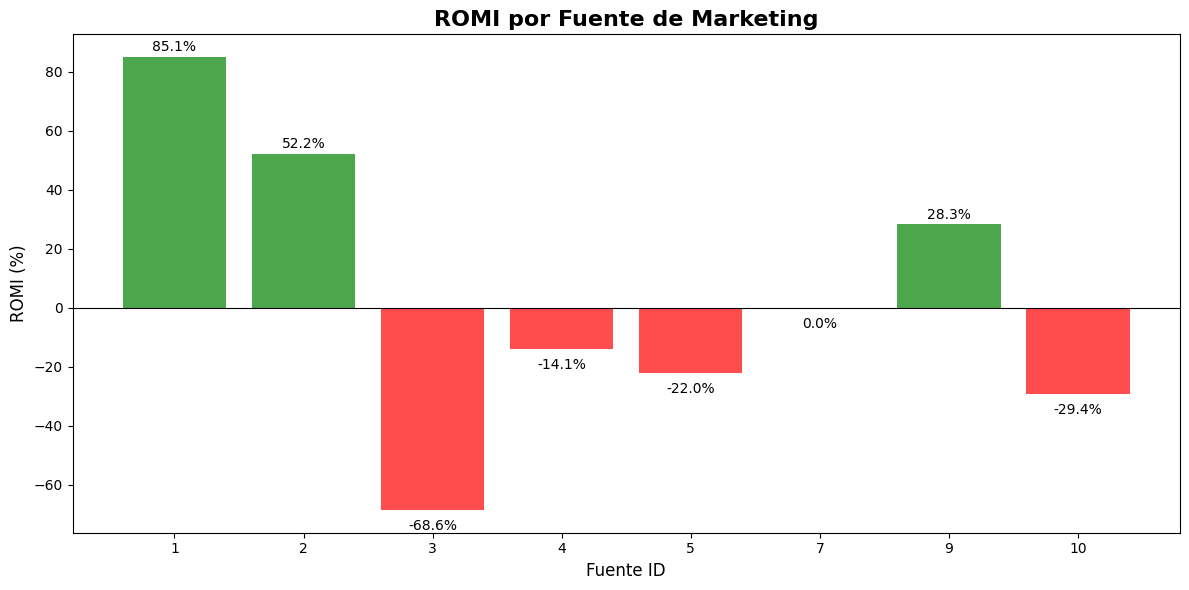

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 6))

# Crear colores: verde para ROMI positivo, rojo para negativo
colors = ['green' if x > 0 else 'red' for x in romi_by_source['romi']]

# Crear el gráfico de barras
bars = ax.bar(romi_by_source.index.astype(str), 
              romi_by_source['romi'] * 100,  # Convertir a porcentaje
              color=colors, alpha=0.7)

# Personalizar el gráfico
ax.set_title('ROMI por Fuente de Marketing', fontsize=16, fontweight='bold')
ax.set_xlabel('Fuente ID', fontsize=12)
ax.set_ylabel('ROMI (%)', fontsize=12)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (1 if height > 0 else -3),
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

plt.tight_layout()
plt.show()

En esta gráfica de barras se muestra el rendimiento general de cada fuente, podemos ver que las fuentes mas rentables son la 1, 2 y 9 en ese orden, por otro lado las no rentables y que deberian tener una revision del departamento de marketin serian las fuentes 3,4,5 y 10 (todas generando perdidas significativas para el negocio)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime

# Crear datos mensuales
# Agregar columna de mes a orders y costs
orders_with_source['month'] = orders_with_source['Buy Ts'].dt.to_period('M')
costs['month'] = costs['dt'].dt.to_period('M')

# Ingresos mensuales por fuente
monthly_revenue = orders_with_source.groupby(['source_id', 'month'])['Revenue'].sum().reset_index()

# Gastos mensuales por fuente
monthly_costs = costs.groupby(['source_id', 'month'])['costs'].sum().reset_index()

# Combinar ingresos y gastos
monthly_data = monthly_revenue.merge(monthly_costs, on=['source_id', 'month'], how='outer').fillna(0)

# Calcular ROMI mensual
monthly_data['romi'] = (monthly_data['Revenue'] / monthly_data['costs']) - 1
monthly_data['romi'] = monthly_data['romi'].replace([float('inf'), -float('inf')], 0)

print("Datos mensuales preparados:")
print(monthly_data.head(10))

Datos mensuales preparados:
   source_id    month  Revenue    costs      romi
0          1  2017-06  1168.45  1125.61  0.038059
1          1  2017-07  1985.01  1072.88  0.850170
2          1  2017-08  1251.84   951.81  0.315220
3          1  2017-09  3730.05  1502.01  1.483372
4          1  2017-10  3772.12  2315.75  0.628898
5          1  2017-11  4311.32  2445.16  0.763206
6          1  2017-12  4015.47  2341.20  0.715133
7          1  2018-01  3262.29  2186.18  0.492233
8          1  2018-02  3235.70  2204.48  0.467784
9          1  2018-03  4813.36  1893.09  1.542594


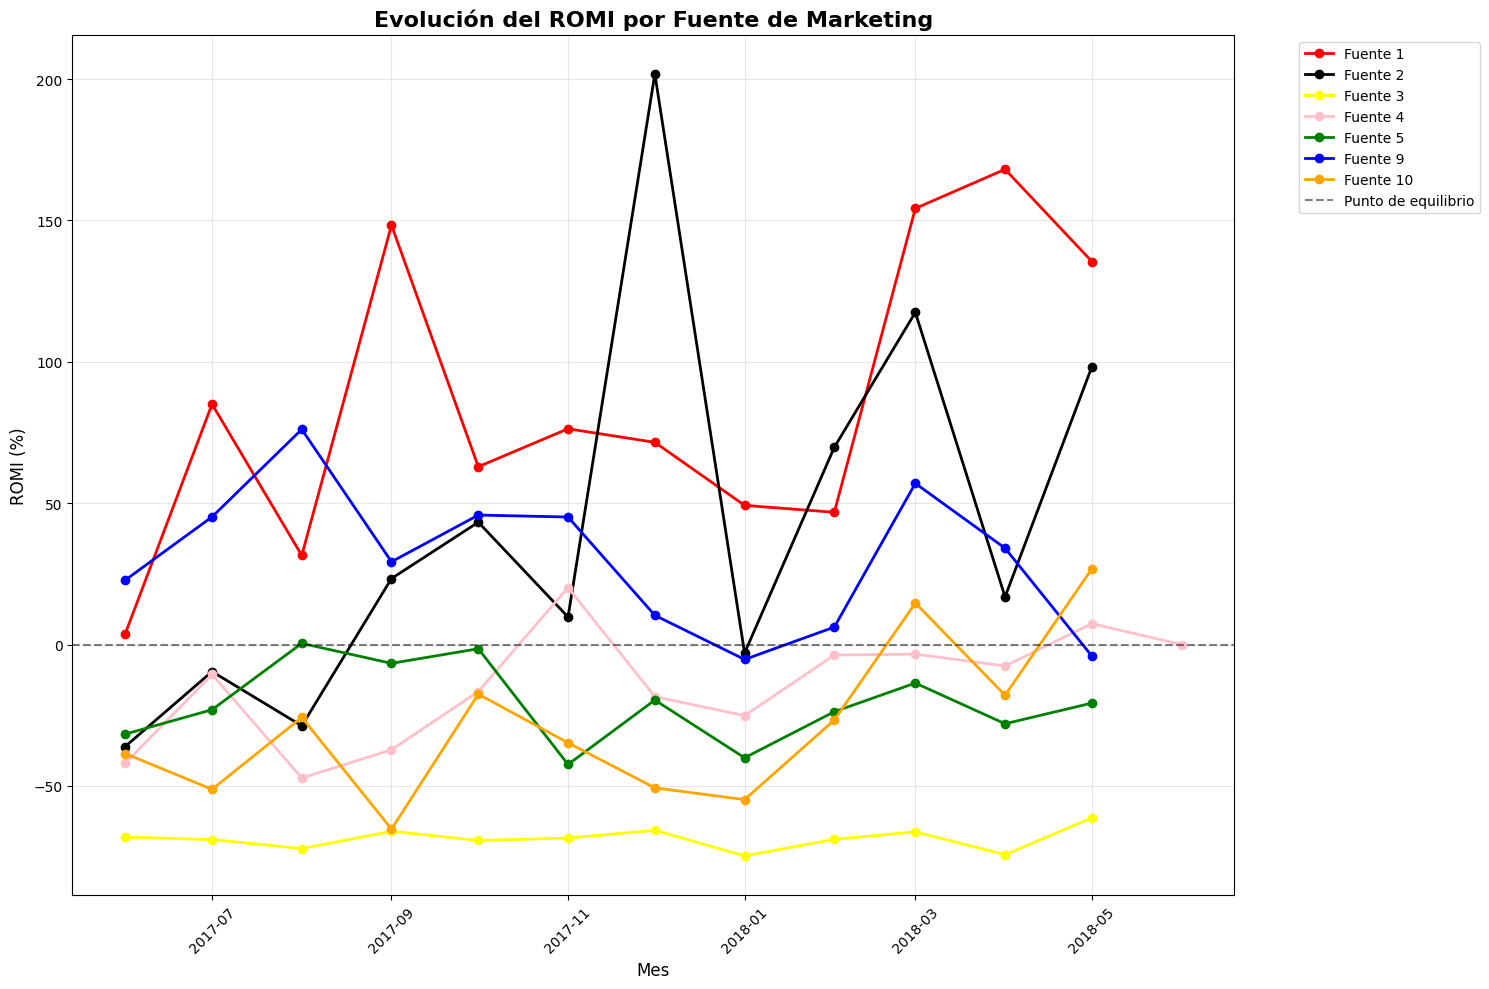

In [44]:
# Crear gráfico para ROMI temporal
plt.figure(figsize=(15, 10))

main_sources = [1, 2, 3, 4, 5, 9, 10]
colors = ['red', 'black', 'yellow', 'pink', 'green', 'blue', 'orange']

for i, source in enumerate(main_sources):
    source_data = monthly_data[monthly_data['source_id'] == source].copy()
    if len(source_data) > 0:
    
        source_data['month_dt'] = source_data['month'].dt.to_timestamp()
        
        plt.plot(source_data['month_dt'], 
                source_data['romi'] * 100,  
                marker='o', 
                linewidth=2, 
                label=f'Fuente {source}',
                color=colors[i % len(colors)])

# Personalizar el gráfico
plt.title('Evolución del ROMI por Fuente de Marketing', fontsize=16, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('ROMI (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Punto de equilibrio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En esta gráfica delíneas se muestra cómo ha cambiado el rendimiento a lo largo del tiempo. Aqui observamos algunos comportamientos como:

La fuente 9, es menos estable pero con menor variación. Esto sugiere que es una fuente "predecible" aunque no la más rentable. 

Sobre las Fuentes 1 y 2:
- Son tus de mejor rendiemiento en el tiempo tambien - alta rentabilidad y buen comportamiento.

Se evidencia una alta variabilidad sin tendencias claras puede indicar varios factores, como competencia, estacionalidad, campañas de marketing, entre otros.


# CONCLUSIÓN Y RECOMENDACIONES ESTRATÉGICAS

Basándonos específicamente en el retorno de la inversión realizada por la empresa en marketing para la captura de clientes podemos realizar el siguiente análisis
Este ejercicio revela una ineficiencia significativa en la asignación del presupuesto de marketing con un ROMI general negativo de -23.42%, lo que significa que por cada dólar invertido se pierden 23 centavos. Las fuentes con el mejor retorno de la inversión son la 1 y 2, por lo que estas serían las que recomendaría utilizar de forma prioritaria. 

Considerando que la fuente 3, es la que mayor perdida está generando, un 68% del valor invertido, recomendaría disminuir a un 10% el presupuesto invertido en marketing para esta fuente lo cual liberaría  $127,000 aproximadamente para reasignación.

La propuesta seria la siguiente en cuanto asignación presupuestal en marketing:
PRESUPUESTO (329,132 total):
1. Fuente 1: 25% = 82,283 (vs. actual 20,833)
2. Fuente 2: 20% = 65,826 (vs. actual 42,806)
3. Fuente 9: 15% = 49,370 (vs. actual 5,517) - Estable y rentable
4. Fuente 3: 10% = 32,913 (vs. actual 141,322) - Reducción del 77%
5. Fuentes 4, 5, 10: Eliminar gradualmente .(todas con ROMI negativo) e ir reasignando a las demás.(todas con ROMI negativo)
Impacto Proyectado
Con esta redistribución se estima:
- **ROMI** general: De -23.42% a +35-40%
- Ahorro en pérdidas: ~95,000 anuales
- Ingresos adicionales: ~60,000 por mejor asignación
La clave del éxito está en invertir donde los datos demuestran rentabilidad, no donde tradicionalmente se ha invertido.

Es importante que la empresa evalúe periódicamente los resultados de estos ajustes para así poder tomar medidas a corto plazo y evitar pérdidas mayores, como las que se vienen presentando actualmente en una sola fuente.